# Writer Summary Metrics Analysis

Use this notebook to compare model performance from a `*_writer_metric_scores.csv` file.

The metrics compare AI-generated summaries against the freelance writer summaries from the paper release.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

## Load Metrics

In [2]:
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "spec.md").exists() and (PROJECT_ROOT.parent / "spec.md").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RESULTS_DIR = PROJECT_ROOT / "results"

# Set this to a specific file if you do not want the latest metrics file.
# Example: METRICS_FILE = RESULTS_DIR / "20260519_232753_writer_metric_scores.csv"
METRICS_FILE = None

if METRICS_FILE is None:
    metric_files = sorted(
        RESULTS_DIR.glob("*_writer_metric_scores.csv"),
        key=lambda path: path.stat().st_mtime,
        reverse=True,
    )
    if not metric_files:
        raise FileNotFoundError(f"No writer metric score files found in {RESULTS_DIR}")
    METRICS_FILE = metric_files[0]

df = pd.read_csv(METRICS_FILE)
print(f"Loaded: {METRICS_FILE}")
print(f"Rows: {len(df):,}")
print(f"Unique articles: {df['id'].nunique():,}")
print(f"Models: {df['model'].nunique():,}")

df.head()

Loaded: C:\Users\fangw\162 proj\results\20260519_232753_writer_metric_scores.csv
Rows: 660
Unique articles: 76
Models: 3


,run_id,id,writer_reference_id,dataset,provider,model,reference_type,rouge1_fmeasure,rouge2_fmeasure,rougeL_fmeasure,meteor,bertscore_precision,bertscore_recall,bertscore_f1
0,20260519_232753,08c88b7d81f148ce95c37ac8a2b0c921,1,writer_summaries,ollama,llama3.1:latest,freelance_writer,0.485437,0.059406,0.233010,0.267293,0.899203,0.900805,0.900003
1,20260519_232753,08c88b7d81f148ce95c37ac8a2b0c921,2,writer_summaries,ollama,llama3.1:latest,freelance_writer,0.314607,0.000000,0.202247,0.152941,0.843321,0.871400,0.857131
2,20260519_232753,08c88b7d81f148ce95c37ac8a2b0c921,3,writer_summaries,ollama,llama3.1:latest,freelance_writer,0.293103,0.070175,0.224138,0.113809,0.873413,0.873526,0.873470
3,20260519_232753,0adb86356834452298d180104ff54179,1,writer_summaries,ollama,llama3.1:latest,freelance_writer,0.294737,0.129032,0.231579,0.197432,0.860767,0.862709,0.861737
4,20260519_232753,0adb86356834452298d180104ff54179,2,writer_summaries,ollama,llama3.1:latest,freelance_writer,0.419753,0.177215,0.246914,0.373619,0.858682,0.882674,0.870513


## Model-Level Averages

In [3]:
METRIC_COLUMNS = [
    "rouge1_fmeasure",
    "rouge2_fmeasure",
    "rougeL_fmeasure",
    "meteor",
    "bertscore_f1",
]

model_summary = (
    df.groupby(["provider", "model"])[METRIC_COLUMNS]
    .agg(["mean", "std", "count"])
    .round(4)
)

model_summary

rouge1_fmeasure               rouge2_fmeasure  \
                                           mean     std count            mean   
provider model                                                                  
ollama   gemma2:9b                       0.3615  0.0886   220          0.1209   
         llama3.1:latest                 0.3926  0.0931   220          0.1330   
openai   gpt-4o-mini-2024-07-18          0.3845  0.0843   220          0.1249   

                                              rougeL_fmeasure                \
                                    std count            mean     std count   
provider model                                                                
ollama   gemma2:9b               0.0726   220          0.2435  0.0710   220   
         llama3.1:latest         0.0778   220          0.2553  0.0730   220   
openai   gpt-4o-mini-2024-07-18  0.0712   220          0.2487  0.0718   220   

                                 meteor               bertscore_f1          \
                                   mean     std count         mean     std   
provider model                                                               
ollama   gemma2:9b               0.2072  0.0804   220       0.8898  0.0164   
         llama3.1:latest         0.2378  0.0841   220       0.8910  0.0181   
openai   gpt-4o-mini-2024-07-18  0.2280  0.0756   220       0.8904  0.0152   

                                       
                                count  
provider model                         
ollama   gemma2:9b                220  
         llama3.1:latest          220  
openai   gpt-4o-mini-2024-07-18   220

## Simple Ranking Table

In [4]:
mean_scores = (
    df.groupby(["provider", "model"], as_index=False)[METRIC_COLUMNS]
    .mean()
    .round(4)
)

for metric in METRIC_COLUMNS:
    mean_scores[f"{metric}_rank"] = mean_scores[metric].rank(ascending=False, method="min").astype(int)

mean_scores["average_rank"] = mean_scores[[f"{metric}_rank" for metric in METRIC_COLUMNS]].mean(axis=1).round(2)
mean_scores = mean_scores.sort_values("average_rank")

mean_scores

,provider,model,rouge1_fmeasure,rouge2_fmeasure,rougeL_fmeasure,meteor,bertscore_f1,rouge1_fmeasure_rank,rouge2_fmeasure_rank,rougeL_fmeasure_rank,meteor_rank,bertscore_f1_rank,average_rank
1,ollama,llama3.1:latest,0.3926,0.1330,0.2553,0.2378,0.8910,1,1,1,1,1,1.0
2,openai,gpt-4o-mini-2024-07-18,0.3845,0.1249,0.2487,0.2280,0.8904,2,2,2,2,2,2.0
0,ollama,gemma2:9b,0.3615,0.1209,0.2435,0.2072,0.8898,3,3,3,3,3,3.0


## Metric Bar Charts

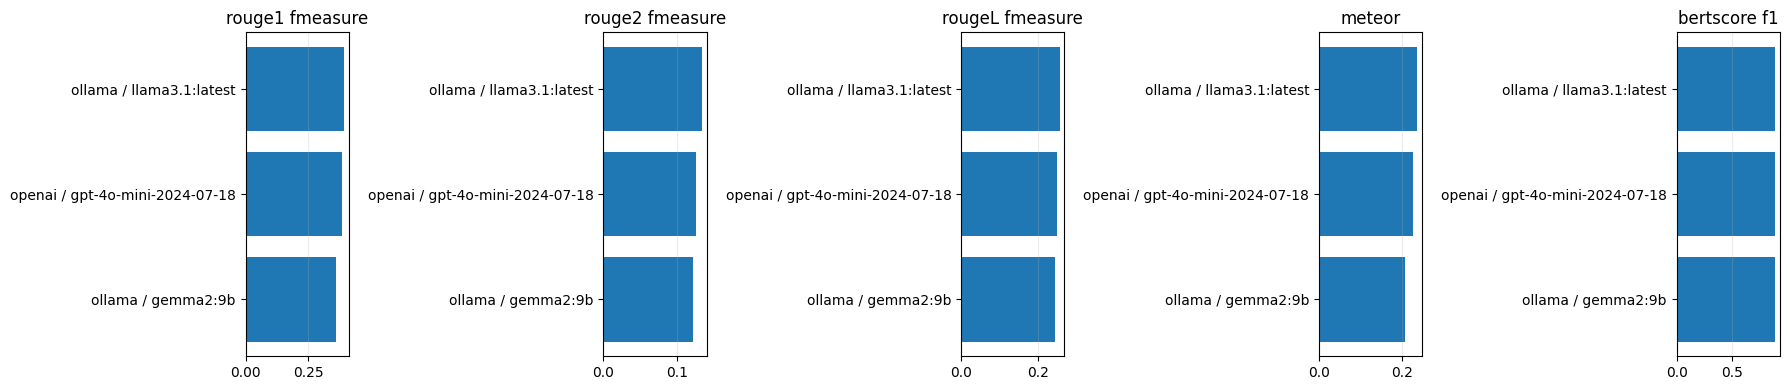

In [5]:
plot_df = mean_scores.copy()
plot_df["model_label"] = plot_df["provider"] + " / " + plot_df["model"]

fig, axes = plt.subplots(1, len(METRIC_COLUMNS), figsize=(18, 4), sharex=False)
for ax, metric in zip(axes, METRIC_COLUMNS):
    ordered = plot_df.sort_values(metric, ascending=True)
    ax.barh(ordered["model_label"], ordered[metric])
    ax.set_title(metric.replace("_", " "))
    ax.grid(axis="x", alpha=0.25)

plt.tight_layout()
plt.show()

## Score Distributions

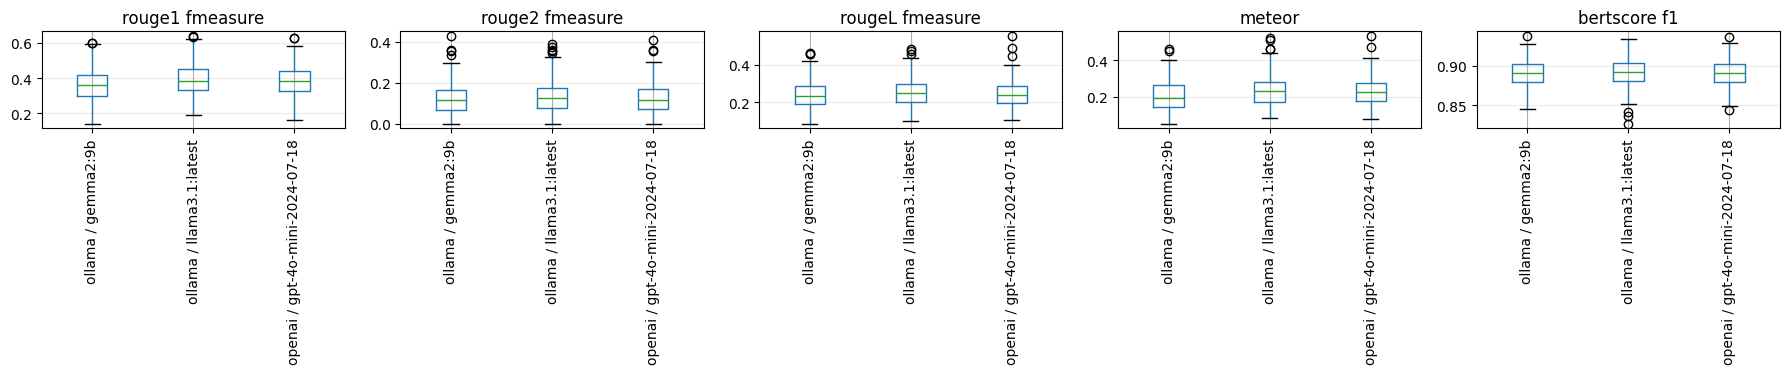

In [6]:
df_plot = df.copy()
df_plot["model_label"] = df_plot["provider"] + " / " + df_plot["model"]

fig, axes = plt.subplots(1, len(METRIC_COLUMNS), figsize=(18, 4), sharex=False)
for ax, metric in zip(axes, METRIC_COLUMNS):
    df_plot.boxplot(column=metric, by="model_label", ax=ax, rot=90)
    ax.set_title(metric.replace("_", " "))
    ax.set_xlabel("")
    ax.grid(axis="y", alpha=0.25)

plt.suptitle("")
plt.tight_layout()
plt.show()

## Article-Level Winners

In [7]:
article_model_scores = (
    df.groupby(["id", "provider", "model"], as_index=False)[METRIC_COLUMNS]
    .mean()
)
article_model_scores["model_label"] = article_model_scores["provider"] + " / " + article_model_scores["model"]

winner_tables = []
for metric in METRIC_COLUMNS:
    winners = article_model_scores.loc[
        article_model_scores.groupby("id")[metric].idxmax(),
        ["id", "model_label", metric],
    ]
    winner_counts = winners["model_label"].value_counts().rename_axis("model_label").reset_index(name=f"{metric}_wins")
    winner_tables.append(winner_counts)

article_winners = winner_tables[0]
for table in winner_tables[1:]:
    article_winners = article_winners.merge(table, on="model_label", how="outer")

article_winners = article_winners.fillna(0).sort_values("rougeL_fmeasure_wins", ascending=False)
article_winners

,model_label,rouge1_fmeasure_wins,rouge2_fmeasure_wins,rougeL_fmeasure_wins,meteor_wins,bertscore_f1_wins
1,ollama / llama3.1:latest,34,34,35,43,31
2,openai / gpt-4o-mini-2024-07-18,28,24,23,21,24
0,ollama / gemma2:9b,14,18,18,12,21


## Plain-English Summary

In [8]:
best_by_metric = {}
for metric in METRIC_COLUMNS:
    row = mean_scores.sort_values(metric, ascending=False).iloc[0]
    best_by_metric[metric] = f"{row['provider']} / {row['model']} ({row[metric]:.4f})"

print("Best model by average metric:")
for metric, winner in best_by_metric.items():
    print(f"- {metric}: {winner}")

print("\nOverall average-rank ordering:")
for _, row in mean_scores.iterrows():
    print(f"- {row['provider']} / {row['model']}: average rank {row['average_rank']}")

Best model by average metric:
- rouge1_fmeasure: ollama / llama3.1:latest (0.3926)
- rouge2_fmeasure: ollama / llama3.1:latest (0.1330)
- rougeL_fmeasure: ollama / llama3.1:latest (0.2553)
- meteor: ollama / llama3.1:latest (0.2378)
- bertscore_f1: ollama / llama3.1:latest (0.8910)

Overall average-rank ordering:
- ollama / llama3.1:latest: average rank 1.0
- openai / gpt-4o-mini-2024-07-18: average rank 2.0
- ollama / gemma2:9b: average rank 3.0
